In [1]:
import numpy as np

In [2]:
import pandas as pd

In [3]:
import seaborn as sns

In [4]:
import matplotlib.pyplot as plt

In [33]:
from sklearn.preprocessing import StandardScaler

In [34]:
from sklearn.cluster import KMeans

In [35]:
from sklearn.model_selection import train_test_split

In [36]:
from sklearn.ensemble import RandomForestClassifier

In [37]:
from sklearn.metrics import classification_report, silhouette_score

In [5]:
walmart= pd.read_csv("D:/Downloads/Walmart.csv")

# Data Exploration

In [6]:
walmart.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [7]:
walmart.tail()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
6430,45,28-09-2012,713173.95,0,64.88,3.997,192.013558,8.684
6431,45,05-10-2012,733455.07,0,64.89,3.985,192.170412,8.667
6432,45,12-10-2012,734464.36,0,54.47,4.000,192.327265,8.667
6433,45,19-10-2012,718125.53,0,56.47,3.969,192.330854,8.667
6434,45,26-10-2012,760281.43,0,58.85,3.882,192.308899,8.667


In [8]:
walmart.nunique()

Store             45
Date             143
Weekly_Sales    6435
Holiday_Flag       2
Temperature     3528
Fuel_Price       892
CPI             2145
Unemployment     349
dtype: int64

In [9]:
walmart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [10]:
 walmart.isnull().sum()

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

# DATA Cleaning 

In [11]:
walmart.drop_duplicates(inplace=True)

In [12]:
walmart['Date'] = pd.to_datetime(walmart['Date'],dayfirst=True)

In [13]:
walmart.isnull().sum()

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

# relationship analysis

In [14]:
correlation=walmart.corr()

<AxesSubplot:>

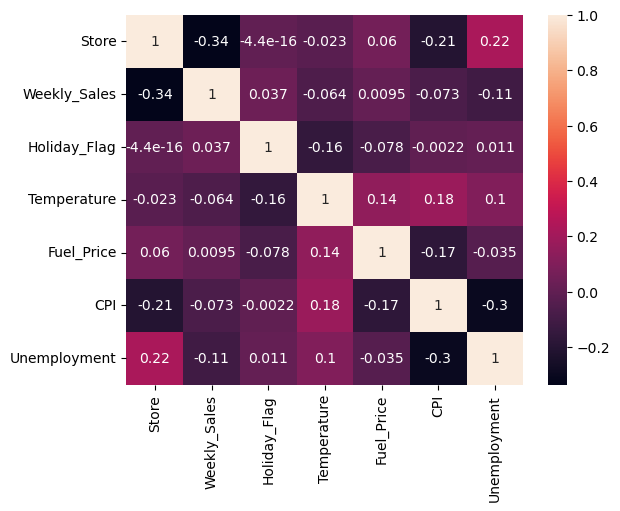

In [15]:
sns.heatmap(correlation,xticklabels=correlation.columns,yticklabels=correlation.columns,annot=True)

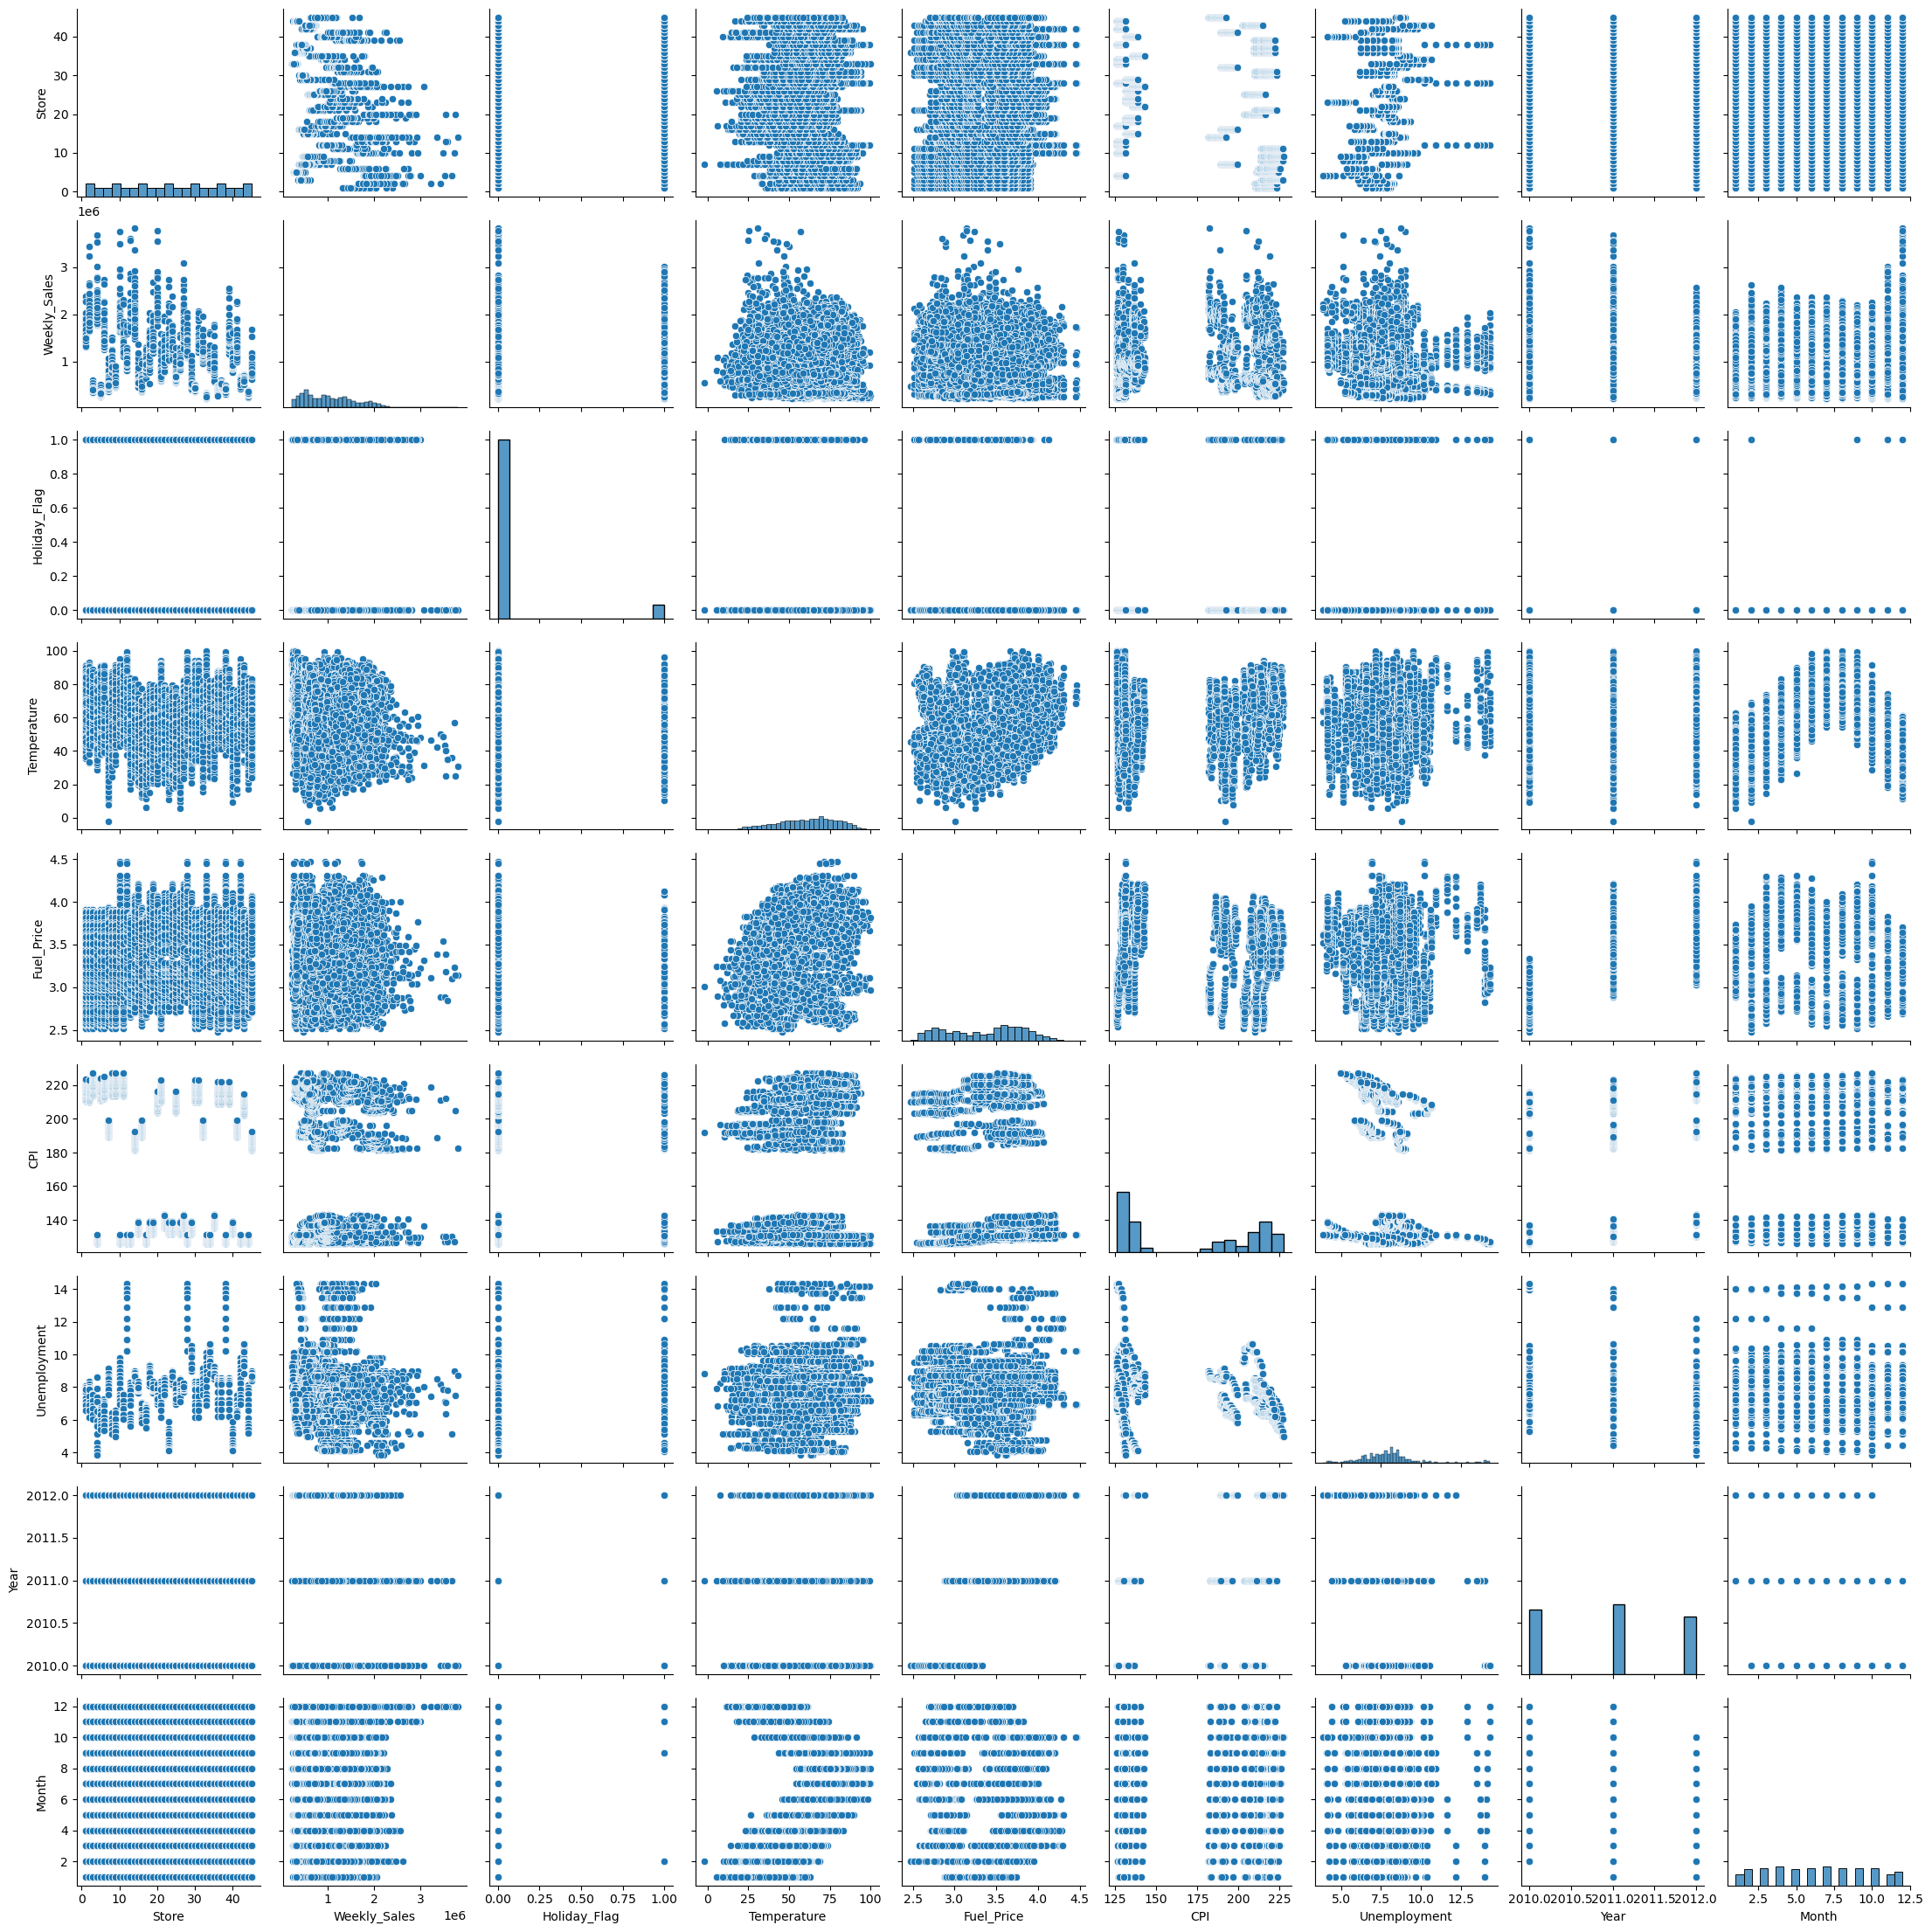

In [27]:
sns.pairplot(walmart)

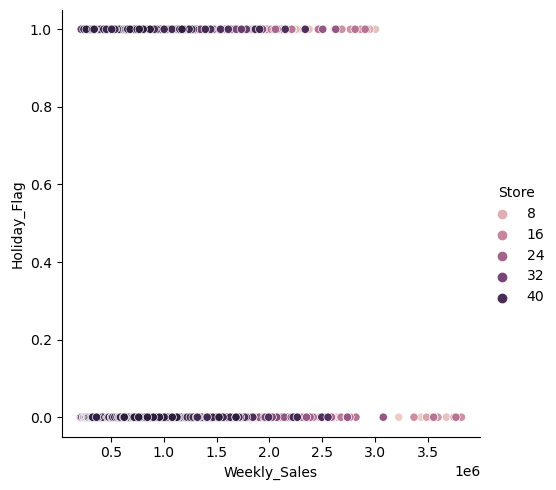

In [28]:
sns.relplot(x='Weekly_Sales',y='Holiday_Flag',hue='Store',data=walmart)

<AxesSubplot:xlabel='Weekly_Sales', ylabel='Count'>

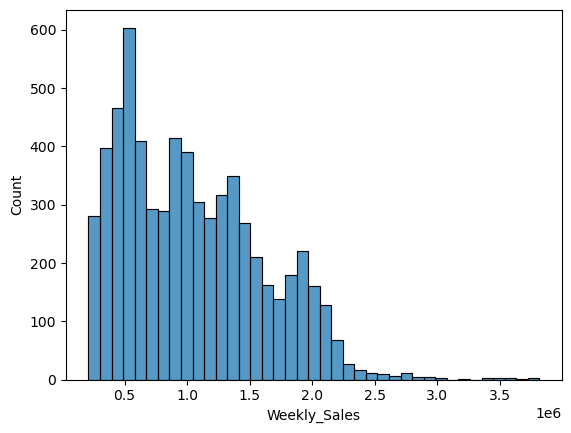

In [18]:
sns.histplot(walmart['Weekly_Sales'])

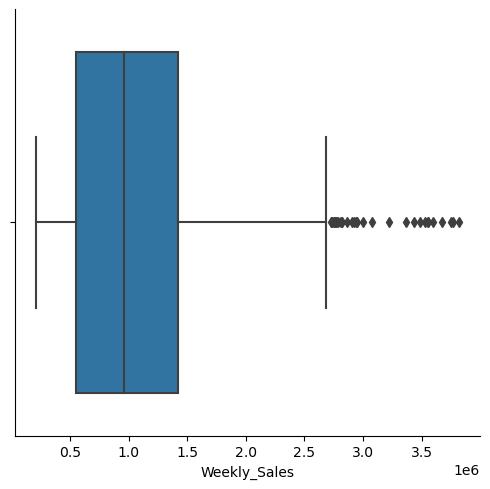

In [19]:
sns.catplot(x='Weekly_Sales',kind='box',data=walmart)

In [29]:
walmart['Date'] = pd.to_datetime(walmart['Date'], dayfirst=True)

Text(0.5, 1.0, 'Weekly Sales Over Time')

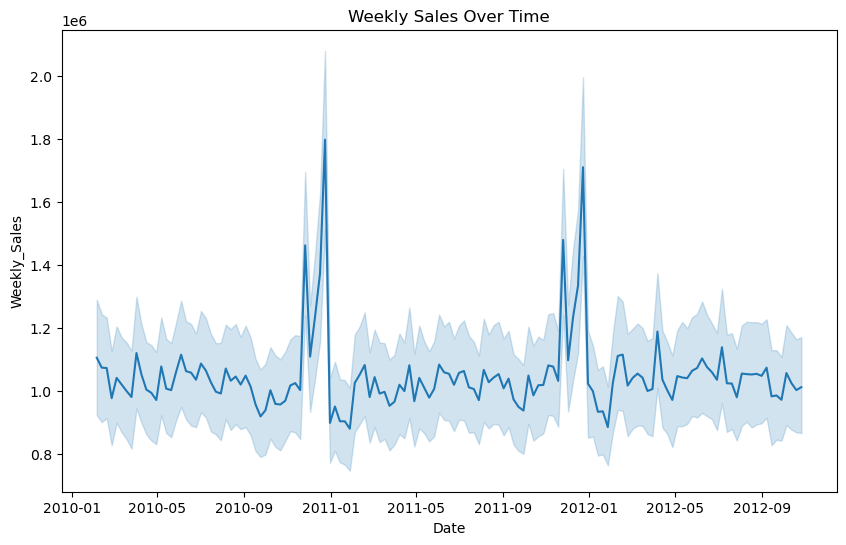

In [21]:
plt.figure(figsize=(10,6))
sns.lineplot(x='Date',y='Weekly_Sales',data=walmart)
plt.title('Weekly Sales Over Time')

In [30]:
walmart['Year']=walmart['Date'].dt.year

In [31]:
walmart['Month']=walmart['Date'].dt.month

In [24]:
sales_by_year = walmart.groupby('Year')['Weekly_Sales'].sum()
print("\n--- Sales by Year ---")
print(sales_by_year)


--- Sales by Year ---
Year
2010    2.288886e+09
2011    2.448200e+09
2012    2.000133e+09
Name: Weekly_Sales, dtype: float64


<Figure size 1000x500 with 0 Axes>

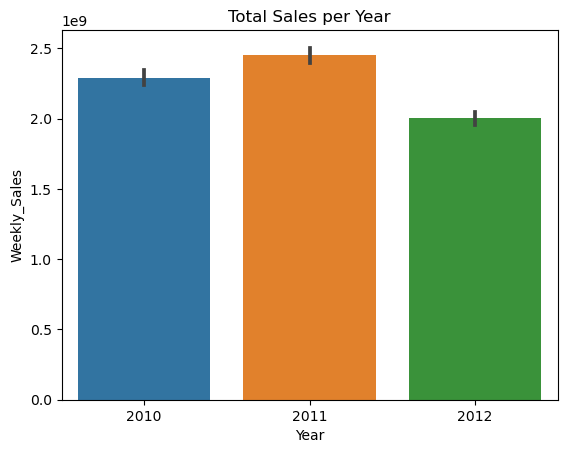

<Figure size 1000x500 with 0 Axes>

In [25]:
plt.title('Total Sales per Year')
sns.barplot(x='Year',y='Weekly_Sales', data=walmart,estimator=sum)
plt.figure(figsize=(10,5))


<Figure size 1000x500 with 0 Axes>

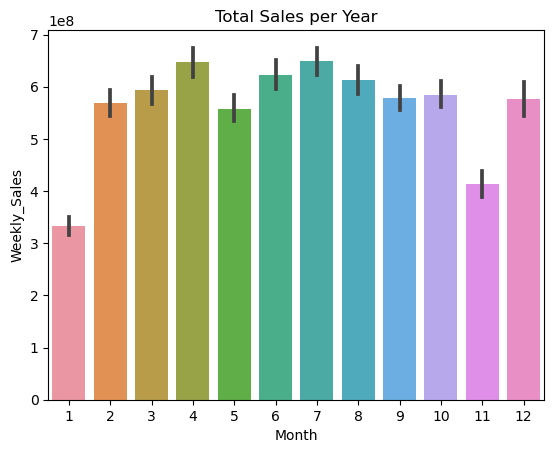

<Figure size 1000x500 with 0 Axes>

In [26]:
plt.title('Total Sales per Year')
sns.barplot(x='Month',y='Weekly_Sales', data=walmart,estimator=sum)
plt.figure(figsize=(10,5))

#STORE SEGMENTATION USING K-MEANS

# Standardization

In [38]:
scaler = StandardScaler()

In [42]:
store_walmart= walmart.groupby('Store').agg({
    'Weekly_Sales': ['sum','mean'],
    'Holiday_Flag': 'sum',
    'Temperature': 'mean',
    'Fuel_Price': 'mean',
    'CPI': 'mean',
    'Unemployment': 'mean'
}).reset_index()

In [43]:
store_walmart.columns = ['Store','Total_Sales','Avg_Sales',
                    'Holiday_Count','Avg_Temp',
                    'Avg_Fuel','Avg_CPI','Avg_Unemployment']

In [44]:
features = store_walmart[['Total_Sales','Avg_Sales',
                     'Holiday_Count','Avg_Temp',
                     'Avg_Fuel','Avg_CPI','Avg_Unemployment']]

In [45]:
scaled_features = scaler.fit_transform(features)

# Elbow plot

In [46]:
sse = []

In [47]:
for k in range(2,8):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(scaled_features)
    sse.append(model.inertia_)

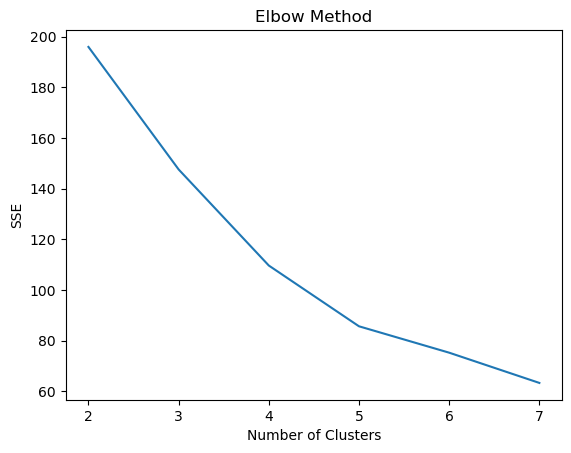

In [55]:
plt.plot(range(2,8), sse)
plt.xlabel("Number of Clusters")
plt.ylabel("SSE")
plt.title("Elbow Method")
plt.show()

# Applying K-Means

In [61]:
kmeans = KMeans(n_clusters=5, random_state=42)
store_walmart['Segment'] = kmeans.fit_predict(scaled_features)

print(store_walmart.groupby('Segment').mean())

             Store   Total_Sales     Avg_Sales  Holiday_Count   Avg_Temp  \
Segment                                                                    
0        27.875000  1.192541e+08  8.339451e+05           10.0  51.128820   
1        17.111111  2.557038e+08  1.788139e+06           10.0  57.097257   
2        21.333333  7.775755e+07  5.437591e+05           10.0  68.891904   
3        30.600000  1.010873e+08  7.069042e+05           10.0  71.951552   
4        15.000000  2.204273e+08  1.541449e+06           10.0  69.691480   

         Avg_Fuel     Avg_CPI  Avg_Unemployment  
Segment                                          
0        3.362208  156.844087          7.876862  
1        3.454542  147.294658          7.398963  
2        3.217977  215.945417          7.398301  
3        3.594221  128.679669         11.249113  
4        3.219699  216.493885          7.418508  


In [63]:
median_sales = store_walmart['Total_Sales'].median()

store_walmart['High_Performer'] = np.where(
    store_walmart['Total_Sales'] >= median_sales, 1, 0
)

# TRAIN MODEL

In [64]:
X = store_walmart[['Avg_Sales','Holiday_Count',
              'Avg_Temp','Avg_Fuel',
              'Avg_CPI','Avg_Unemployment']]

In [66]:
y = store_walmart['High_Performer']

In [67]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [71]:
model = RandomForestClassifier()

In [72]:
model.fit(X_train, y_train)

RandomForestClassifier()

In [73]:
y_pred = model.predict(X_test)

In [74]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.83      0.91         6
           1       0.75      1.00      0.86         3

    accuracy                           0.89         9
   macro avg       0.88      0.92      0.88         9
weighted avg       0.92      0.89      0.89         9



# Feature Importance

In [76]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(importance)

            Feature  Importance
0         Avg_Sales    0.710633
2          Avg_Temp    0.112153
5  Avg_Unemployment    0.072569
3          Avg_Fuel    0.055852
4           Avg_CPI    0.048793
1     Holiday_Count    0.000000


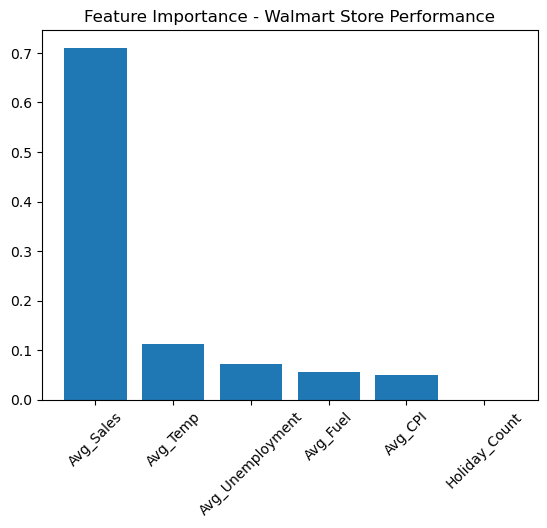

In [77]:
plt.figure()
plt.bar(importance['Feature'], importance['Importance'])
plt.xticks(rotation=45)
plt.title("Feature Importance - Walmart Store Performance")
plt.show()